In [22]:
import spectra_to_models as s
import pickle
import importlib

In [60]:
importlib.reload(s)

<module 'spectra_to_models' from '/Users/rahmbharara/Desktop/Peng_proj_clean/spectra_to_models.py'>

In [ ]:
full_dict = ...

In [85]:
with open("simulate_videos/overall_dict_diff_coeff_0p04_final.pkl", "rb") as f:  # "rb" = read binary
    full_dict = pickle.load(f)

In [10]:
full_dict["Er0p5Tm02Yb97p5"].keys()

dict_keys([1, 2, 5, 10, 20, 50])

Right now, I have:

`full_dict[particle_type][frame_avg] = [data_for_particle_0, data_for_particle_1, ...]`

but the code needs the structure 

`full_dict[particle_type][particle_id][frame_avg] = data`

In [86]:
new_full_dict = {}

for ptcl_type, frame_dict in full_dict.items():
    new_full_dict[ptcl_type] = {}

    num_particles = len(next(iter(frame_dict.values())))

    for i in range(num_particles):
        new_full_dict[ptcl_type][i] = {}

        for f, data_list in frame_dict.items():
            new_full_dict[ptcl_type][i][f] = [data_list[i][0], data_list[i][1]-80]  # POSSIBLY CHANGE DEPENDING ON DICT!!!

In [87]:
full_dict = new_full_dict

In [88]:
frame_avgs = [1, 2, 5, 10, 20, 50]
particle_types = ['Er0p5Tm02Yb97p5', 'Er01Tm02Yb20_NEW_PMAO', 'Er01Tm05Yb94_NEW_PMAO', 'Er02Tm01Yb97_NEW_PMAO',
                  'Er02Tm05Yb93', 'Er02Yb20', 'Er04Yb13', 'Tm01Yb99', 'Tm02Yb98', 'Tm10Yb90']

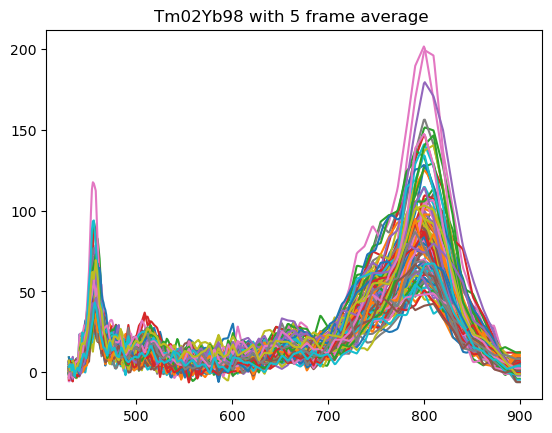

In [89]:
s.graph_particle_type(particle_types[8], 5, full_dict, normalized=False)

In [90]:
# generate this all-encompassing CSV file
min_wavelength, max_wavelength = s.get_min_and_max(1, full_dict)
s.create_complete_csv_data(min_wavelength, max_wavelength, frame_avgs, full_dict, "final_simulated_data_0p04_diff")

In [91]:
best_model = 'rf'
best_params = {
    'n_estimators': 500, 
    'min_samples_leaf': 1, 
    'max_depth': 10
    }

# these are the estimated based params (for now) overall across all frame-average types found by systematically testing
# a grid of different model types and hyperparams
# could possibly be improved later

Training accuracy: 1.000
Accuracy:          0.895
Balanced accuracy: 0.895

Classification report:
                       precision    recall  f1-score   support

Er01Tm02Yb20_NEW_PMAO       0.84      0.80      0.82        20
Er01Tm05Yb94_NEW_PMAO       0.83      0.75      0.79        20
Er02Tm01Yb97_NEW_PMAO       1.00      1.00      1.00        20
         Er02Tm05Yb93       0.71      0.75      0.73        20
             Er02Yb20       1.00      1.00      1.00        20
             Er04Yb13       1.00      1.00      1.00        20
      Er0p5Tm02Yb97p5       0.76      0.80      0.78        20
             Tm01Yb99       0.94      0.85      0.89        20
             Tm02Yb98       0.91      1.00      0.95        20
             Tm10Yb90       0.95      1.00      0.98        20

             accuracy                           0.90       200
            macro avg       0.90      0.89      0.89       200
         weighted avg       0.90      0.90      0.89       200



/Users/rahmbharara/Desktop/Peng_proj_clean/spectra_to_models.py:355: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.22)


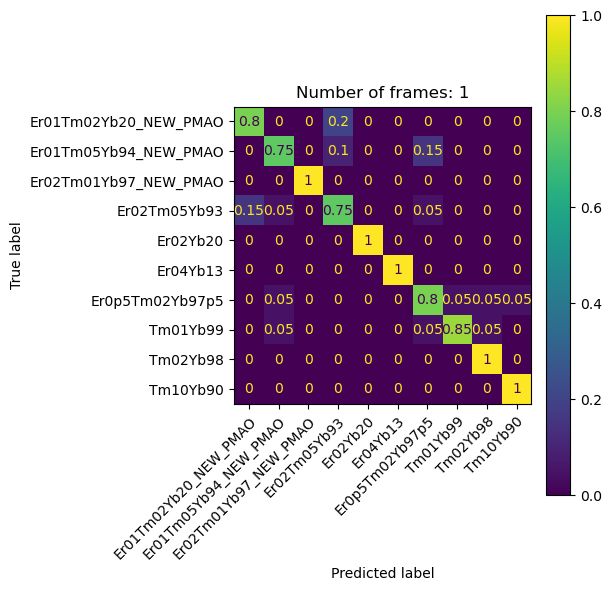

Training accuracy: 1.000
Accuracy:          0.940
Balanced accuracy: 0.940

Classification report:
                       precision    recall  f1-score   support

Er01Tm02Yb20_NEW_PMAO       0.95      1.00      0.98        20
Er01Tm05Yb94_NEW_PMAO       0.84      0.80      0.82        20
Er02Tm01Yb97_NEW_PMAO       1.00      1.00      1.00        20
         Er02Tm05Yb93       1.00      0.90      0.95        20
             Er02Yb20       0.95      1.00      0.98        20
             Er04Yb13       1.00      0.95      0.97        20
      Er0p5Tm02Yb97p5       0.76      0.80      0.78        20
             Tm01Yb99       0.95      0.95      0.95        20
             Tm02Yb98       0.95      1.00      0.98        20
             Tm10Yb90       1.00      1.00      1.00        20

             accuracy                           0.94       200
            macro avg       0.94      0.94      0.94       200
         weighted avg       0.94      0.94      0.94       200



/Users/rahmbharara/Desktop/Peng_proj_clean/spectra_to_models.py:355: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.22)


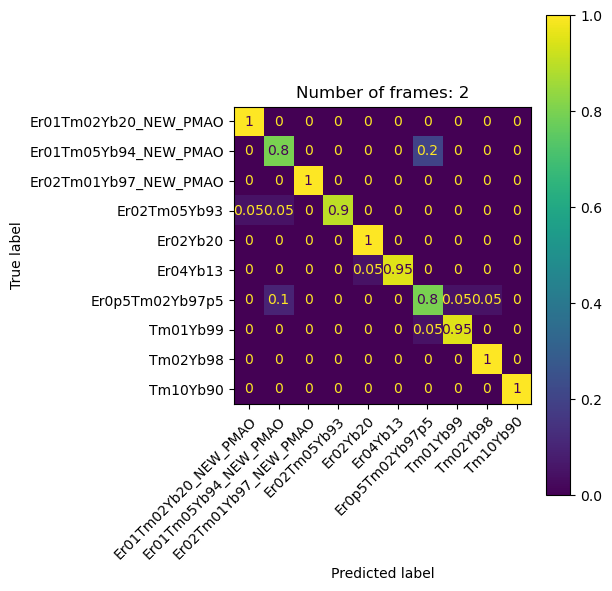

Training accuracy: 1.000
Accuracy:          0.950
Balanced accuracy: 0.950

Classification report:
                       precision    recall  f1-score   support

Er01Tm02Yb20_NEW_PMAO       0.95      0.95      0.95        20
Er01Tm05Yb94_NEW_PMAO       0.90      0.90      0.90        20
Er02Tm01Yb97_NEW_PMAO       1.00      1.00      1.00        20
         Er02Tm05Yb93       0.94      0.85      0.89        20
             Er02Yb20       0.95      1.00      0.98        20
             Er04Yb13       1.00      0.95      0.97        20
      Er0p5Tm02Yb97p5       0.86      0.95      0.90        20
             Tm01Yb99       1.00      0.90      0.95        20
             Tm02Yb98       0.91      1.00      0.95        20
             Tm10Yb90       1.00      1.00      1.00        20

             accuracy                           0.95       200
            macro avg       0.95      0.95      0.95       200
         weighted avg       0.95      0.95      0.95       200



/Users/rahmbharara/Desktop/Peng_proj_clean/spectra_to_models.py:355: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.22)


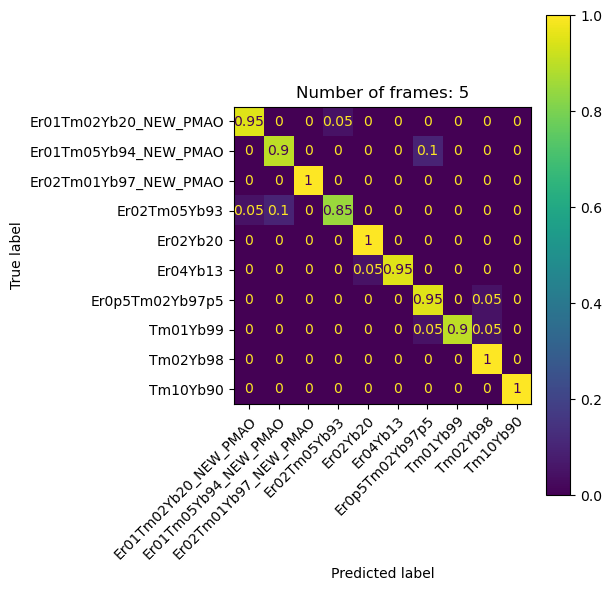

Training accuracy: 1.000
Accuracy:          0.965
Balanced accuracy: 0.965

Classification report:
                       precision    recall  f1-score   support

Er01Tm02Yb20_NEW_PMAO       1.00      0.95      0.97        20
Er01Tm05Yb94_NEW_PMAO       0.95      0.95      0.95        20
Er02Tm01Yb97_NEW_PMAO       1.00      1.00      1.00        20
         Er02Tm05Yb93       0.95      0.95      0.95        20
             Er02Yb20       0.95      0.95      0.95        20
             Er04Yb13       0.95      0.95      0.95        20
      Er0p5Tm02Yb97p5       0.95      0.95      0.95        20
             Tm01Yb99       0.95      1.00      0.98        20
             Tm02Yb98       0.95      0.95      0.95        20
             Tm10Yb90       1.00      1.00      1.00        20

             accuracy                           0.96       200
            macro avg       0.97      0.96      0.96       200
         weighted avg       0.97      0.96      0.96       200



/Users/rahmbharara/Desktop/Peng_proj_clean/spectra_to_models.py:355: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.22)


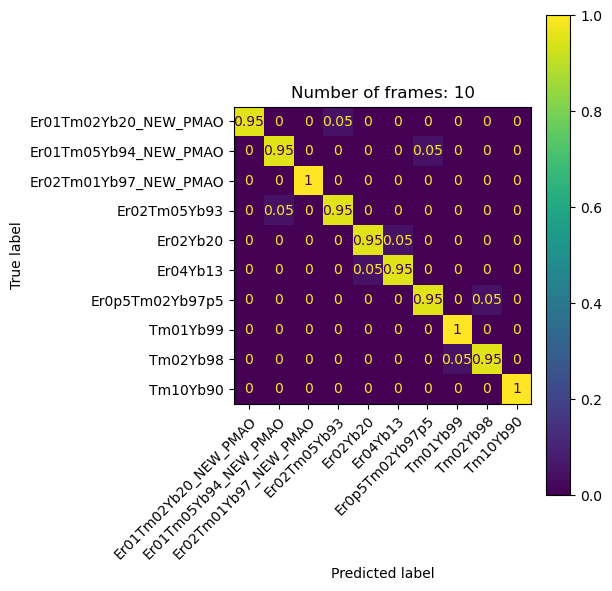

Training accuracy: 1.000
Accuracy:          0.970
Balanced accuracy: 0.970

Classification report:
                       precision    recall  f1-score   support

Er01Tm02Yb20_NEW_PMAO       1.00      1.00      1.00        20
Er01Tm05Yb94_NEW_PMAO       0.95      0.90      0.92        20
Er02Tm01Yb97_NEW_PMAO       1.00      1.00      1.00        20
         Er02Tm05Yb93       1.00      0.95      0.97        20
             Er02Yb20       0.95      0.95      0.95        20
             Er04Yb13       0.95      0.95      0.95        20
      Er0p5Tm02Yb97p5       0.90      0.95      0.93        20
             Tm01Yb99       1.00      1.00      1.00        20
             Tm02Yb98       0.95      1.00      0.98        20
             Tm10Yb90       1.00      1.00      1.00        20

             accuracy                           0.97       200
            macro avg       0.97      0.97      0.97       200
         weighted avg       0.97      0.97      0.97       200



/Users/rahmbharara/Desktop/Peng_proj_clean/spectra_to_models.py:355: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.22)


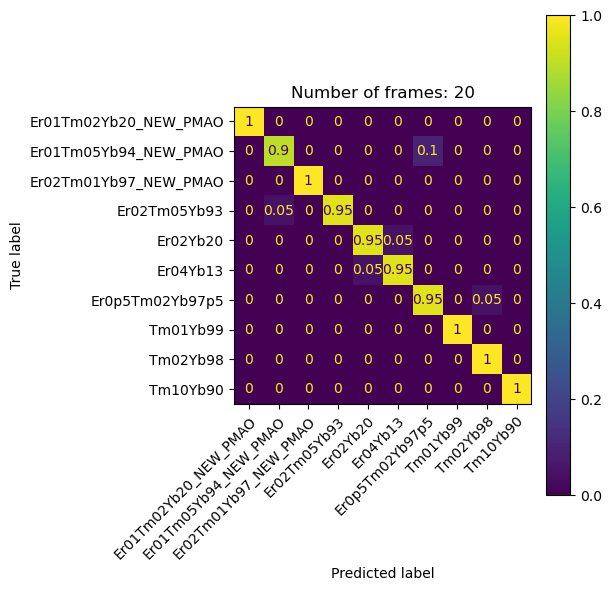

Training accuracy: 1.000
Accuracy:          0.965
Balanced accuracy: 0.965

Classification report:
                       precision    recall  f1-score   support

Er01Tm02Yb20_NEW_PMAO       1.00      0.95      0.97        20
Er01Tm05Yb94_NEW_PMAO       0.90      0.95      0.93        20
Er02Tm01Yb97_NEW_PMAO       1.00      1.00      1.00        20
         Er02Tm05Yb93       0.95      0.95      0.95        20
             Er02Yb20       1.00      1.00      1.00        20
             Er04Yb13       1.00      1.00      1.00        20
      Er0p5Tm02Yb97p5       0.90      0.90      0.90        20
             Tm01Yb99       0.95      1.00      0.98        20
             Tm02Yb98       0.95      0.95      0.95        20
             Tm10Yb90       1.00      0.95      0.97        20

             accuracy                           0.96       200
            macro avg       0.97      0.96      0.97       200
         weighted avg       0.97      0.96      0.97       200



/Users/rahmbharara/Desktop/Peng_proj_clean/spectra_to_models.py:355: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.22)


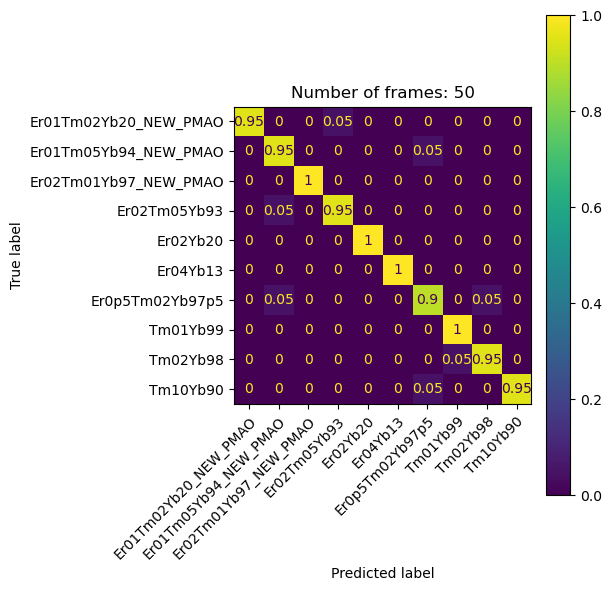

In [92]:
import joblib

for frame_avg in frame_avgs:
    this_frame_model = s.classifier(frame_avg, 'unif', best_model, "final_simulated_data_0p04_diff_430to900.csv", plot_the_results=True, **best_params)['clf']
    joblib.dump(this_frame_model, f"trained_models_sim_video/diff_coeff_0p04/{frame_avg}frame_classifier.pkl")